In [ ]:
# https://www.mdpi.com/2076-3417/12/19/10077

In [1]:
import numpy as np
import random

SEED = 42
# Set global seeds
np.random.seed(SEED)
random.seed(SEED)

In [2]:
import os
# !pwd

from pathlib import Path

# dir_path = Path(r"/Users/rabinatwayana/Rabina/CDE II/Wildfire Project/SAR-Burnt-Area-Mapping/")
dir_path = Path(r"/Users/rabinatwayana/1_Rabina/CDE II/Wildfire Project/SAR-Burnt-Area-Mapping/")

if dir_path.exists():
    os.chdir(dir_path)
else:
    print("Directory does not exist! Please check the path.")

from pathlib import Path
folder_path = Path("MachineLearning/output/model/")
folder_path.mkdir(parents=True, exist_ok=True)

folder_path = Path("MachineLearning/output/feature_importance/")
folder_path.mkdir(parents=True, exist_ok=True)
default_n_jobs=7



In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from utils import run_model, create_fish_net, run_optuna_param_tuning, prepare_training_sample
import config
from sklearn.ensemble import RandomForestClassifier

TILE_SIZE=config.TILE_SIZE
from datetime import datetime

/Users/rabinatwayana/miniforge3/envs/wildfire_burnt_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
hyperparameter_tuning=True
gt_image_path="MachineLearning/input/ground_truth/02_gt/gt_palisade.tif"
rgb_image_path="MachineLearning/input/S2/rgbn_clip.tif"

113


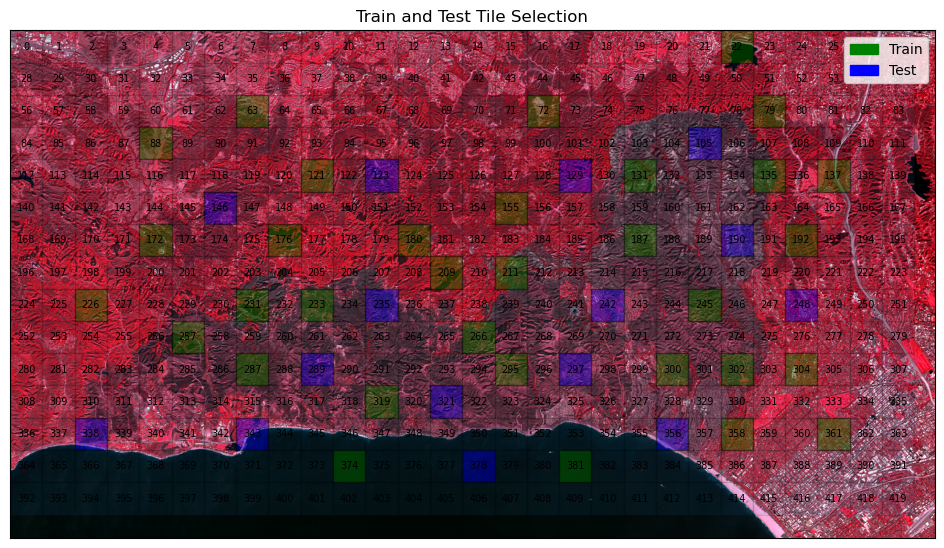

Fishnet tile generation done


In [5]:

train_ids = [131, 135,88,172,361,63,79,300,211,287,257,226,176,180,187,209,155,121,72,22,137,192,304,358,374,381,245,302,295,266,233,319,231]
test_ids = [146,129,123,343,378,248,190,242,297,321,235,356, 338, 105,289]

tiles=create_fish_net("MachineLearning/input/sar/02_clip/S1A_asc_32611_avg_clip.tif", rgb_image_path, tile_size=TILE_SIZE,plot_fig=True,train_ids=train_ids,test_ids=test_ids)


In [6]:
def run_hyperparameter_tuning(schemes, model_name):
    best_params={}
    if schemes["scheme_1"]:
        print("******* scheme 1 *********")
        file_name="palisades_sar_single_asc"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_1"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)

    if schemes["scheme_2"]:
        print("******* scheme 2 *********")
        file_name="palisades_sar_single_desc"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_2"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)

    if schemes["scheme_3"]:
        print("******* scheme 3 *********")
        file_name="palisades_sar_single_asc_desc"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_3"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)
        
    if schemes["scheme_4"]:
        print("******* scheme 4 *********")
        file_name="palisades_sar_single_asc_desc_glcm"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_4"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)
        

    if schemes["scheme_5"]:
        print("******* scheme 5 *********")
        file_name="palisades_sar_avg_asc"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_5"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)


    if schemes["scheme_6"]:
        print("******* scheme 6 *********")
        file_name="palisades_sar_avg_desc"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_6"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)

    if schemes["scheme_7"]:
        print("******* scheme 7 *********")
        file_name="palisades_sar_avg_asc_desc"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_7"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)
        
    if schemes["scheme_8"]:
        print("******* scheme 8 *********")
        file_name="palisades_sar_avg_asc_desc_glcm"
        feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif"
        best_params["scheme_8"]=run_optuna_param_tuning(model_name,feature_image_path,gt_image_path,train_ids,TILE_SIZE)
    return best_params

def run_experiments(schemes, model_name, best_params):
    output_model_dir="MachineLearning/output/model/"
    output_feat_imp_dir="MachineLearning/output/feature_importance/"

    feature_column_names=["RBD_VV", "RBD_VH", "RBR_VV", "RBR_VH","ΔRVI"]
    feature_column_names_with_glcm=["RBD_VV", "RBD_VH", "RBR_VV", "RBR_VH","ΔRVI",'p1','p2','p3']
    metrics_combined=[]
    train_duration={}
    file_names={
        "scheme_1":"palisades_sar_single_asc",
        "scheme_2":"palisades_sar_single_desc",
        "scheme_3":"palisades_sar_single_asc_desc",
        "scheme_4":"palisades_sar_single_asc_desc_glcm",
        "scheme_5":"palisades_sar_avg_asc",
        "scheme_6":"palisades_sar_avg_desc",
        "scheme_7":"palisades_sar_avg_asc_desc",
        "scheme_8":"palisades_sar_avg_asc_desc_glcm"
    }
    # glcm_feature_column_names=['p1','p2','p3']
    # best_param={}

    for scheme in best_params.keys():
        print(f"Running {scheme}...")
        best_params_scheme=best_params[scheme]
        if model_name=="RandomForest":
            print(f"Best hyperparameters for {scheme}: {best_params_scheme}")
            model=RandomForestClassifier(
                n_estimators= 300, 
                n_jobs=default_n_jobs,
                random_state=42,
                max_depth=best_params_scheme['max_depth'],
                min_samples_leaf=best_params_scheme['min_samples_leaf'],
                min_samples_split= best_params_scheme['min_samples_split'], 
                max_features= best_params_scheme['max_features'],
                class_weight=best_params_scheme['class_weight'],
            )
        else:
            print(f"Best hyperparameters for {scheme}: {best_params_scheme}")
            model = XGBClassifier(
                        n_estimators=best_params_scheme['n_estimators'],
                        objective="binary:logistic",
                        eval_metric="logloss",
                        random_state=42,
                        n_jobs=default_n_jobs,
                        tree_method="hist",
                        # early_stopping_rounds=10,
                        verbosity=0,
                        max_depth=best_params_scheme['max_depth'],
                        learning_rate=best_params_scheme['learning_rate'],
                        subsample=best_params_scheme['subsample'],
                        colsample_bytree=best_params_scheme['colsample_bytree'],
                        min_child_weight=best_params_scheme['min_child_weight'],
                        gamma=best_params_scheme['gamma'],
                        reg_alpha=best_params_scheme['reg_alpha'],
                        reg_lambda=best_params_scheme['reg_lambda'],
                        # verbosity=0,
                        # max_depth=12,
                        # learning_rate=0.061,
                        # subsample=0.679,
                        # colsample_bytree=0.805,
                        # min_child_weight=6,
                        # gamma=0.232,
                        # reg_alpha=3.037,
                        # reg_lambda=0.852,
                    )
        
        start_timestamp = datetime.now()
        
        file_name=file_names[scheme]
        print(f"Running model for {scheme} with file: {file_name}")
        metrics_1=run_model(
                feature_image_path=f"MachineLearning/output/feature_image/{file_name}.tif", 
                    gt_image_path=gt_image_path,
                    feature_column_names= feature_column_names_with_glcm if scheme in ['scheme_4','scheme_8'] else feature_column_names, 
                    model_name=model_name,
                    model=model, #scheme_3_model,
                    # model_param=best_param,
                    output_model_dir=output_model_dir,
                    output_feat_imp_dir=output_feat_imp_dir,
                    extended_file_name=f"_{file_name}",
                    train_ids=train_ids, 
                    test_ids=test_ids, 
                    tile_size=TILE_SIZE
                )
        metrics_combined.append(metrics_1)
        end_timestamp=datetime.now()
        total_time=end_timestamp-start_timestamp
        train_duration[scheme]=total_time
        # train_duration['scheme_1']=total_time

    print(metrics_combined)
    # Convert to DataFrame
    df_metrics = pd.DataFrame(metrics_combined)

    # Save to CSV
    df_metrics.to_csv(f'MachineLearning/output/{model_name}_evaluation_metrics.csv', index=False)

    print("==== Evaluation metrics saved to CSV ====")

    print("Train Duration for each scheme:")
    for scheme, duration in train_duration.items():
        print(f"{scheme}: {duration}")

In [7]:
schemes={
    "scheme_1": True,
    "scheme_2": True,
    "scheme_3": True,
    "scheme_4": True,
    "scheme_5": True,
    "scheme_6": True,
    "scheme_7": True,
    "scheme_8": True
}

### Hyperparameter Tuning Random Forest

In [9]:
model_name="RandomForest"
best_params_rf_result=run_hyperparameter_tuning(schemes, model_name)
print("Best Hyperparameters for Random Forest:", best_params_rf_result)

[I 2026-03-02 12:46:51,457] A new study created in memory with name: no-name-7789c693-2ea9-4551-93d5-004a539ed834


******* scheme 1 *********
cpu_cores 7
Fishnet tile generation done
Using GroupKFold with split  3
Using 10 n-trials for optuna parameter tuning


[I 2026-03-02 12:47:31,856] Trial 0 finished with value: 0.79183 and parameters: {'max_depth': 12, 'min_samples_leaf': 6, 'min_samples_split': 15, 'max_features': 0.7394633936788146, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.79183.
[I 2026-03-02 12:48:05,526] Trial 1 finished with value: 0.79049 and parameters: {'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 13, 'max_features': 0.7832290311184182, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.79183.
[I 2026-03-02 12:48:44,469] Trial 2 finished with value: 0.79587 and parameters: {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}. Best is trial 2 with value: 0.79587.
[I 2026-03-02 12:49:17,085] Trial 3 finished with value: 0.79455 and parameters: {'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 13, 'max_features': 0.5557975442608167, 'class_weight': 'balanced_subsample'}. Best is trial

[{'trial_number': 0, 'train_f1_score_mean': np.float64(0.843771), 'train_f1_score_std': np.float64(0.003639), 'val_f1_score_mean': np.float64(0.791829), 'val_f1_score_std': np.float64(0.015254), 'params': {'rf__max_depth': 12, 'rf__min_samples_leaf': 6, 'rf__min_samples_split': 15, 'rf__max_features': 0.7394633936788146, 'rf__class_weight': 'balanced'}}, {'trial_number': 1, 'train_f1_score_mean': np.float64(0.820374), 'train_f1_score_std': np.float64(0.004274), 'val_f1_score_mean': np.float64(0.790486), 'val_f1_score_std': np.float64(0.016047), 'params': {'rf__max_depth': 8, 'rf__min_samples_leaf': 6, 'rf__min_samples_split': 13, 'rf__max_features': 0.7832290311184182, 'rf__class_weight': 'balanced_subsample'}}, {'trial_number': 2, 'train_f1_score_mean': np.float64(0.900595), 'train_f1_score_std': np.float64(0.001826), 'val_f1_score_mean': np.float64(0.795874), 'val_f1_score_std': np.float64(0.013441), 'params': {'rf__max_depth': 18, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 

[I 2026-03-02 12:54:09,806] A new study created in memory with name: no-name-807cc945-aadf-4eaf-a422-7ae72700705f


...

[{'trial_number': 0, 'train_f1_score_mean': np.float64(0.863824), 'train_f1_score_std': np.float64(0.001915), 'val_f1_score_mean': np.float64(0.807201), 'val_f1_score_std': np.float64(0.018743), 'params': {'rf__max_depth': 12, 'rf__min_samples_leaf': 6, 'rf__min_samples_split': 15, 'rf__max_features': 0.7394633936788146, 'rf__class_weight': 'balanced'}}, {'trial_number': 1, 'train_f1_score_mean': np.float64(0.839306), 'train_f1_score_std': np.float64(0.001994), 'val_f1_score_mean': np.float64(0.804196), 'val_f1_score_std': np.float64(0.022088), 'params': {'rf__max_depth': 8, 'rf__min_samples_leaf': 6, 'rf__min_samples_split': 13, 'rf__max_features': 0.7832290311184182, 'rf__class_weight': 'balanced_subsample'}}, {'trial_number': 2, 'train_f1_score_mean': np.float64(0.924077), 'train_f1_score_std': np.float64(0.006547), 'val_f1_score_mean': np.float64(0.808934), 'val_f1_score_std': np.float64(0.011116), 'params': {'rf__max_depth': 18, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 

[I 2026-03-02 13:50:00,788] A new study created in memory with name: no-name-3e968132-8525-40e3-b404-580eabef40b6


Fishnet tile generation done
Using GroupKFold with split  3
Using 10 n-trials for optuna parameter tuning


[I 2026-03-02 13:51:19,735] Trial 0 finished with value: 0.8114 and parameters: {'max_depth': 12, 'min_samples_leaf': 6, 'min_samples_split': 15, 'max_features': 0.7394633936788146, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8114.
[I 2026-03-02 13:52:29,679] Trial 1 finished with value: 0.80365 and parameters: {'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 13, 'max_features': 0.7832290311184182, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.8114.
[I 2026-03-02 13:53:55,497] Trial 2 finished with value: 0.81419 and parameters: {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}. Best is trial 2 with value: 0.81419.
[I 2026-03-02 13:55:04,148] Trial 3 finished with value: 0.8126 and parameters: {'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 13, 'max_features': 0.5557975442608167, 'class_weight': 'balanced_subsample'}. Best is trial 2 w

[{'trial_number': 0, 'train_f1_score_mean': np.float64(0.889046), 'train_f1_score_std': np.float64(0.001429), 'val_f1_score_mean': np.float64(0.811396), 'val_f1_score_std': np.float64(0.022325), 'params': {'rf__max_depth': 12, 'rf__min_samples_leaf': 6, 'rf__min_samples_split': 15, 'rf__max_features': 0.7394633936788146, 'rf__class_weight': 'balanced'}}, {'trial_number': 1, 'train_f1_score_mean': np.float64(0.850573), 'train_f1_score_std': np.float64(0.00461), 'val_f1_score_mean': np.float64(0.803654), 'val_f1_score_std': np.float64(0.027623), 'params': {'rf__max_depth': 8, 'rf__min_samples_leaf': 6, 'rf__min_samples_split': 13, 'rf__max_features': 0.7832290311184182, 'rf__class_weight': 'balanced_subsample'}}, {'trial_number': 2, 'train_f1_score_mean': np.float64(0.954289), 'train_f1_score_std': np.float64(0.00283), 'val_f1_score_mean': np.float64(0.814191), 'val_f1_score_std': np.float64(0.015761), 'params': {'rf__max_depth': 18, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5,

## Model Training Random Forest

Running scheme_1...
Best hyperparameters for scheme_1: {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}
Running model for scheme_1 with file: palisades_sar_single_asc
***************RandomForest*********************
Fishnet tile generation done
Model performance for Training set smooth
Model performance
- Log loss: 2.949135409574401
- Accuracy: 0.9181787878787879
- F1 Score: 0.9005621965000908
- Precision Score: 0.9172083712531222
- Recall Score: 0.8877819835404167
- Roc Auc Score: 0.9618393484242755
- F1 Score Binary: 0.8587082223536245
- Precision Score Binary: 0.9150829764453962
- Recall Score Binary: 0.8088764454784744
- Roc Auc Score Binary: 0.9618393484242755
- confusion_matrix: [[220949   7614]
 [ 19387  82050]]
--------------
Model performance for Test set smooth
Model performance
- Log loss: 7.877941175748038
- Accuracy: 0.7814333333333333
- F1 Score: 0.7686198132583513
- Precision Score:

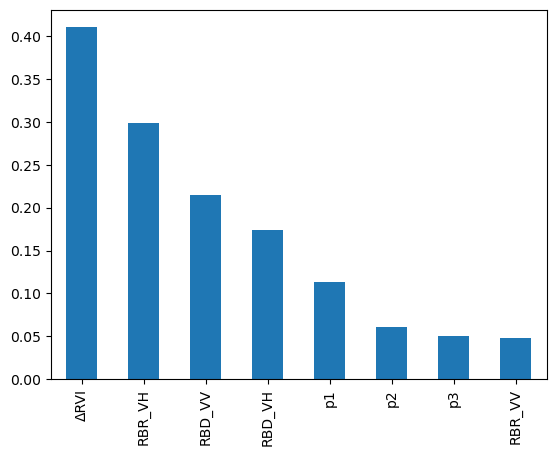

In [10]:
model_name="RandomForest" 
best_params_rf={
'scheme_1': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}, 
 'scheme_2': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}, 
 'scheme_3': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}, 
 'scheme_4': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}, 
 'scheme_5': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}, 
 'scheme_6': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}, 
 'scheme_7': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}, 
 'scheme_8': {'max_depth': 18, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 0.5733618039413735, 'class_weight': 'balanced_subsample'}
 }
run_experiments(schemes, model_name, best_params_rf)

### Hyperparameter Tuning XGboost

In [11]:
model_name="XGBoost"
best_params_xgboost_result = run_hyperparameter_tuning(schemes, model_name)
print("Best Hyperparameters for all schemes: ", best_params_xgboost_result)

[I 2026-03-02 15:36:55,687] A new study created in memory with name: no-name-dae5dfec-fb28-4b3a-a4f9-a1348431bb97


******* scheme 1 *********
cpu_cores 7
Fishnet tile generation done
Using GroupKFold with split  3
Using 10 n-trials for optuna parameter tuning
Using 3 n-splits


[I 2026-03-02 15:36:57,836] Trial 0 finished with value: 0.80066 and parameters: {'max_depth': 10, 'learning_rate': 0.08927180304353628, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 0.80066.


Using 3 n-splits


[I 2026-03-02 15:37:01,326] Trial 1 finished with value: 0.7996 and parameters: {'max_depth': 14, 'learning_rate': 0.051059032093947576, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 1.0616955533913808, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}. Best is trial 0 with value: 0.80066.


...

Using 3 n-splits


[I 2026-03-02 15:42:43,474] Trial 8 finished with value: 0.81857 and parameters: {'max_depth': 9, 'learning_rate': 0.03488960745139221, 'subsample': 0.6563696899899051, 'colsample_bytree': 0.9208787923016158, 'min_child_weight': 1, 'gamma': 4.9344346830025865, 'reg_alpha': 3.861223846483287, 'reg_lambda': 0.993578407670862}. Best is trial 8 with value: 0.81857.


Using 3 n-splits


[I 2026-03-02 15:42:46,568] Trial 9 finished with value: 0.81733 and parameters: {'max_depth': 5, 'learning_rate': 0.06538248584518043, 'subsample': 0.8827429375390468, 'colsample_bytree': 0.8916028672163949, 'min_child_weight': 8, 'gamma': 0.3702232586704518, 'reg_alpha': 1.7923286427213632, 'reg_lambda': 0.5793452976256486}. Best is trial 8 with value: 0.81857.


[{'trial_number': 0, 'train_f1_score_mean': np.float64(0.889193), 'train_f1_score_std': np.float64(0.004943), 'val_f1_score_mean': np.float64(0.816759), 'val_f1_score_std': np.float64(0.009102), 'best_iteration': 32, 'params': {'max_depth': 10, 'learning_rate': 0.08927180304353628, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}}, {'trial_number': 1, 'train_f1_score_mean': np.float64(0.898428), 'train_f1_score_std': np.float64(0.00574), 'val_f1_score_mean': np.float64(0.815822), 'val_f1_score_std': np.float64(0.010555), 'best_iteration': 53, 'params': {'max_depth': 14, 'learning_rate': 0.051059032093947576, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 1.0616955533913808, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}}, {'trial_number': 2, 'train_f1_score_mean': np.floa

### Model Training XGBoost

Running scheme_1...
Best hyperparameters for scheme_1: {'n_estimators': 291, 'max_depth': 13, 'learning_rate': 0.015305744365500184, 'subsample': 0.9878338511058234, 'colsample_bytree': 0.9100531293444458, 'min_child_weight': 10, 'gamma': 4.474136752138244, 'reg_alpha': 2.9894998940554256, 'reg_lambda': 4.609371175115584}
Running model for scheme_1 with file: palisades_sar_single_asc
***************XGBoost*********************
Fishnet tile generation done
Model performance for Training set smooth
Model performance
- Log loss: 4.6775924243707
- Accuracy: 0.8702242424242425
- F1 Score: 0.8341474465788781
- Precision Score: 0.8781257560243366
- Recall Score: 0.8108937281761044
- Roc Auc Score: 0.9139902461366861
- F1 Score Binary: 0.7567948208302573
- Precision Score Binary: 0.8925562268093714
- Recall Score Binary: 0.6568806254128178
- Roc Auc Score Binary: 0.9139902461366861
- confusion_matrix: [[220542   8021]
 [ 34805  66632]]
--------------
Model performance for Test set smooth
Model

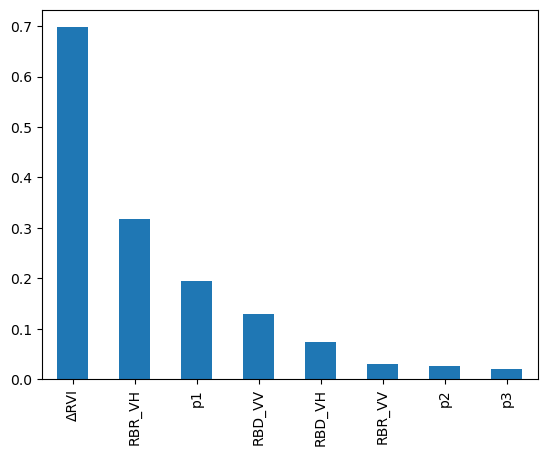

In [9]:
model_name="XGBoost" 
best_params_xgb={
    'scheme_1': {'n_estimators': 291,'max_depth': 13, 'learning_rate': 0.015305744365500184, 'subsample': 0.9878338511058234, 'colsample_bytree': 0.9100531293444458, 'min_child_weight': 10, 'gamma': 4.474136752138244, 'reg_alpha': 2.9894998940554256, 'reg_lambda': 4.609371175115584}, 
    'scheme_2': {'n_estimators': 125,'max_depth': 9, 'learning_rate': 0.03488960745139221, 'subsample': 0.6563696899899051, 'colsample_bytree': 0.9208787923016158, 'min_child_weight': 1, 'gamma': 4.9344346830025865, 'reg_alpha': 3.861223846483287, 'reg_lambda': 0.993578407670862}, 
    'scheme_3': {'n_estimators':337 ,'max_depth': 13, 'learning_rate': 0.015305744365500184, 'subsample': 0.9878338511058234, 'colsample_bytree': 0.9100531293444458, 'min_child_weight': 10, 'gamma': 4.474136752138244, 'reg_alpha': 2.9894998940554256, 'reg_lambda': 4.609371175115584}, 
    'scheme_4': {'n_estimators':184 ,'max_depth': 9, 'learning_rate': 0.03347776308515933, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167, 'min_child_weight': 7, 'gamma': 0.6974693032602092, 'reg_alpha': 1.4607232426760908, 'reg_lambda': 1.8318092164684585}, 
    'scheme_5': {'n_estimators':82 ,'max_depth': 14, 'learning_rate': 0.051059032093947576, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 1.0616955533913808, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}, 
    'scheme_6': {'n_estimators':164 ,'max_depth': 6, 'learning_rate': 0.015703008378806716, 'subsample': 0.6180909155642152, 'colsample_bytree': 0.7301321323053057, 'min_child_weight': 4, 'gamma': 1.3567451588694794, 'reg_alpha': 4.143687545759647, 'reg_lambda': 1.7837666334679465}, 
    'scheme_7': {'n_estimators':36 ,'max_depth': 6, 'learning_rate': 0.08889667907018929, 'subsample': 0.9862528132298237, 'colsample_bytree': 0.9233589392465844, 'min_child_weight': 4, 'gamma': 0.48836057003191935, 'reg_alpha': 3.4211651325607844, 'reg_lambda': 2.2007624686980067}, 
    'scheme_8': {'n_estimators':111 ,'max_depth': 9, 'learning_rate': 0.03488960745139221, 'subsample': 0.6563696899899051, 'colsample_bytree': 0.9208787923016158, 'min_child_weight': 1, 'gamma': 4.9344346830025865, 'reg_alpha': 3.861223846483287, 'reg_lambda': 0.993578407670862}
    }
    
run_experiments(schemes, model_name, best_params_xgb)